<a href="https://colab.research.google.com/github/Ahmedark77/Introduction-to-AI/blob/feature-branch/Assignment_12.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

In [2]:
fashion_mnist = tf.keras.datasets.fashion_mnist
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

class_names = [
    "T-shirt/top","Trouser","Pullover","Dress","Coat",
    "Sandal","Shirt","Sneaker","Bag","Ankle boot"
]

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


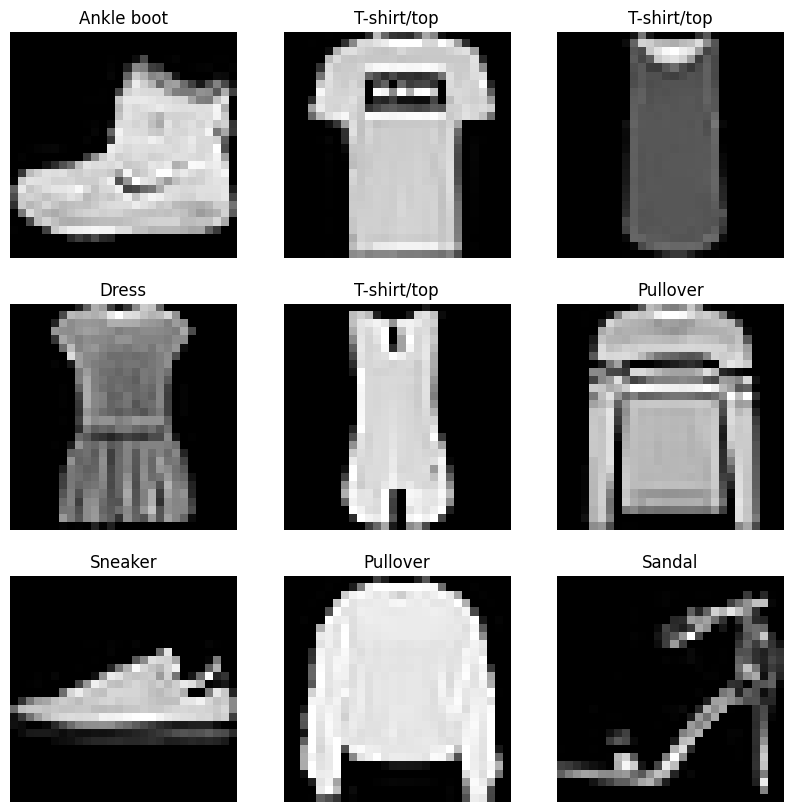

In [3]:
plt.figure(figsize=(10,10))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(class_names[y_train[i]])
    plt.axis('off')
plt.show()

In [4]:
# Normalize pixel values from [0,255] → [0,1]
# This improves convergence during training
x_train = x_train / 255.0
x_test = x_test / 255.0

# Flatten images (28x28 → 784) for feedforward neural network
x_train = x_train.reshape(-1, 28*28)
x_test = x_test.reshape(-1, 28*28)

print("After flattening:", x_train.shape)

After flattening: (60000, 784)


In [5]:
# Create a Sequential model (layer-by-layer architecture)
model = models.Sequential([

    # Input layer + First hidden layer
    layers.Dense(512, activation='relu', input_shape=(784,)),

    # Second hidden layer
    layers.Dense(256, activation='relu'),

    # Output layer (10 classes)
    layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [6]:
model.compile(
    optimizer='adam',                        # Adaptive optimizer
    loss='sparse_categorical_crossentropy', # Best for integer labels
    metrics=['accuracy']                    # Performance metric
)

In [7]:
history = model.fit(
    x_train,
    y_train,
    epochs=15,            # Number of full passes through dataset
    batch_size=64,        # Number of samples per update
    validation_split=0.2, # 20% used for validation
    verbose=1
)

Epoch 1/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 0.8237 - loss: 0.4921 - val_accuracy: 0.8487 - val_loss: 0.4017
Epoch 2/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.8668 - loss: 0.3609 - val_accuracy: 0.8717 - val_loss: 0.3607
Epoch 3/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.8799 - loss: 0.3247 - val_accuracy: 0.8709 - val_loss: 0.3552
Epoch 4/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.8885 - loss: 0.3006 - val_accuracy: 0.8797 - val_loss: 0.3381
Epoch 5/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.8945 - loss: 0.2808 - val_accuracy: 0.8903 - val_loss: 0.3087
Epoch 6/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.9011 - loss: 0.2661 - val_accuracy: 0.8877 - val_loss: 0.3135
Epoch 7/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.9047 - loss: 0.2526 - val_accuracy: 0.8817 - val_loss: 0.3321
Epoch 8/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.9102 - loss: 0.2403 - val

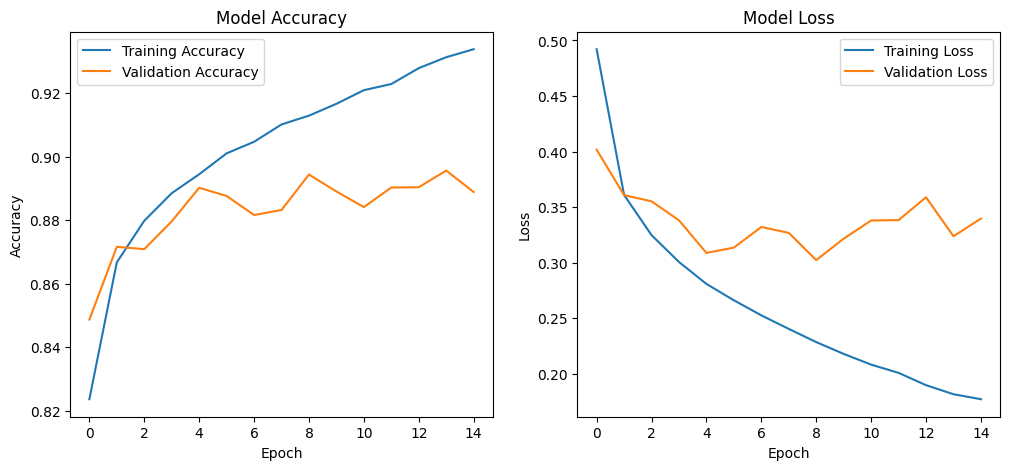

In [8]:
plt.figure(figsize=(12,5))

# Accuracy Plot
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

# Loss Plot
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [9]:
test_loss, test_acc = model.evaluate(x_test, y_test)

print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8831 - loss: 0.3675
Test Accuracy: 0.8831
Test Loss: 0.3675


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


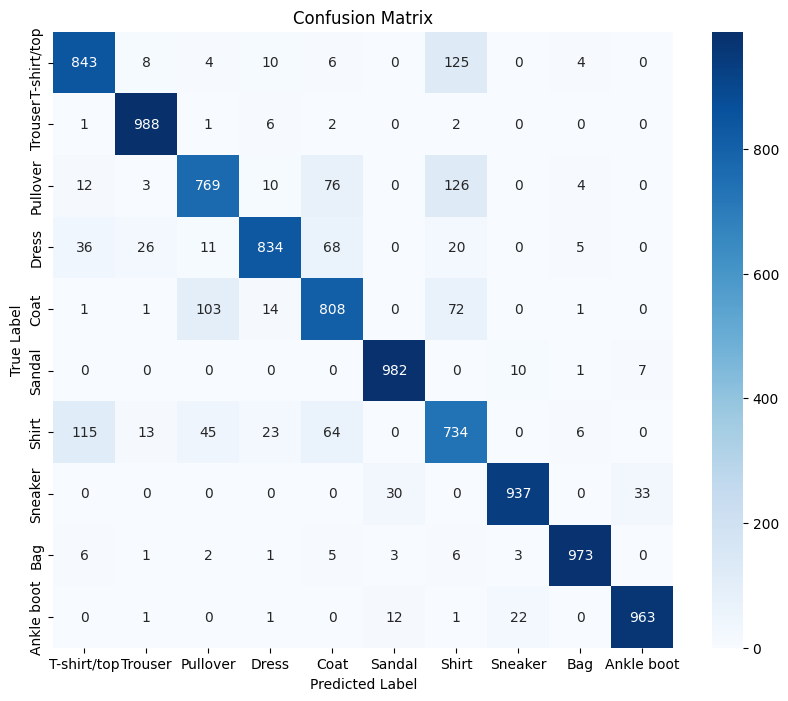

In [10]:
# Predict classes
y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred_classes)

# Plot confusion matrix
plt.figure(figsize=(10,8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step


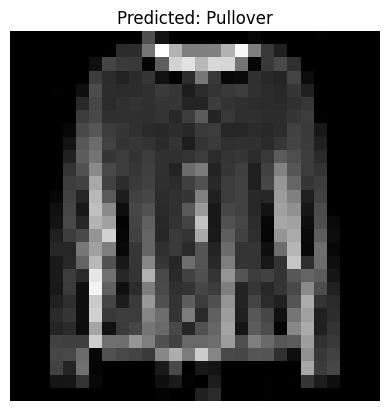

In [11]:
def predict_sample(index):
    # Get image
    img = x_test[index].reshape(1, 784)

    # Predict
    prediction = model.predict(img)
    predicted_class = np.argmax(prediction)

    # Display
    plt.imshow(x_test[index].reshape(28,28), cmap='gray')
    plt.title(f"Predicted: {class_names[predicted_class]}")
    plt.axis('off')
    plt.show()

# Example
predict_sample(25)